In [1]:
import os
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm
import arviz as az
from scipy.stats import gaussian_kde
from pesummary.io import read
from simple_pe.param_est import SimplePESamples
from simple_pe.waveforms import parameter_bounds, two_ecc_harms_snr

import logging
_logger = logging.getLogger('PESummary')
_logger.setLevel(logging.CRITICAL + 10)
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from us

lal.MSUN_SI != Msun


In [19]:
def summary_plot(delta_lbl, inj_lbl, colour_lbl, injections_dir, err_type, resample_log_2_uni=False, ecc_harm_snr=False, use_hdi=True, xlims=None, ylims=None):

    # Loop through injections:
    inj_params = []
    delta_meds = []
    delta_errs = []
    pf_params = []
    c_vals = []
    failed_inds = []
    plot_inds = []
    for i, inj_dir in tqdm(enumerate(sorted(os.listdir(injections_dir)))):
        inj_dir = os.path.join(injections_dir, inj_dir)
        inj_dir = os.path.join(inj_dir, 'outdir/output/')
        plot_inds.append(i)
        # if 'injection_7' in inj_dir:
        #     plot_inds.append(i)
        # else:
        #     inj_params.append(None)
        #     delta_meds.append(None)
        #     delta_errs.append([None, None])
        #     pf_params.append(None)
        #     c_vals.append(None)
        #     continue
        
        # Get inj_param, delta_true, and c_val
        failed = False
        try:
            inj_path = os.path.join(inj_dir, 'converted_injection_parameters.json')
            with open(inj_path, 'r') as f:
                inj_dict = json.load(f)
            inj_param = inj_dict['posterior_samples'][inj_lbl]
            inj_params.append(inj_param[0])
            pf_path = os.path.join(inj_dir, 'peak_parameters.json')
            with open(pf_path, 'r') as f:
                pf_dict = json.load(f)
            psnr_path = os.path.join(inj_dir, 'peak_snrs.json')
            with open(psnr_path, 'r') as f:
                psnr_dict = json.load(f)
            if ecc_harm_snr:
                zr = psnr_dict['posterior_samples']['ecc_harm_snr'][0]
                zi = psnr_dict['posterior_samples']['ecc_harm_snr_imag'][0]
                z = {int(k): zr[k] + 1j*zi[k] for k in zr.keys()}
                harm_ids = [0, 1, -1]
                ecc_snr_abs, _ = two_ecc_harms_snr(
                    {k: np.abs(z[k]) for k in harm_ids},
                    {k: np.angle(z[k]) for k in harm_ids}
                )
                inj_params[-1] = [ecc_snr_abs*np.abs(z[0])]
            delta_true = inj_dict['posterior_samples'][delta_lbl][0]
            c_val = inj_dict['posterior_samples'][colour_lbl]
            c_vals.append(c_val[0])
        except:
            c_vals.append(None)
            failed = True

        # Check run finished properly, if so get samples on delta parameter
        if failed or 'posterior_samples.dat' not in os.listdir(inj_dir):
            failed_inds.append(i)
            delta_meds.append(None)
            delta_errs.append([None, None])
            pf_params.append(None)
        else:
            pf_param = pf_dict['posterior_samples'][delta_lbl][0]
            samples_path = os.path.join(inj_dir, 'posterior_samples.dat')
            samples = SimplePESamples(read(samples_path).samples_dict)
            samples.generate_all_posterior_samples()
            samples_delta = samples[delta_lbl]
            if resample_log_2_uni:
                weights = samples_delta.copy()
                weights /= np.max(weights)
                samples_delta = samples_delta[np.random.uniform(0, 1, len(samples_delta)) < weights]
            if use_hdi:
                hdi = az.hdi(samples_delta, prob=0.9)
                samples_kde = gaussian_kde(samples_delta)
                delta_arr = np.linspace(np.min(samples_delta), np.max(samples_delta), 1001)
                peak = delta_arr[np.argmax(samples_kde(delta_arr))]
                pts = np.array([hdi[0], peak, hdi[1]])
            else:
                pts = np.quantile(samples_delta, [0.05, 0.5, 0.95])
            if err_type == 'rel':
                pts /= delta_true
                pf_param /= delta_true
            elif err_type == 'abs':
                pts -= delta_true
                pf_param -= delta_true
            elif err_type == 'base':
                if delta_lbl != inj_lbl:
                    raise ValueError('delta_lbl must equal inj_lbl for base err_type')
                pts = pts
            else:
                raise ValueError('Incorrect err_type')
            delta_meds.append(pts[1])
            delta_errs.append([pts[1] - pts[0], pts[2] - pts[1]])
            pf_params.append(pf_param)

    # Plot failed runs
    plt.figure(figsize=(10, 7.5))
    if len(failed_inds) > 0:
        if not ecc_harm_snr:
            for ind in failed_inds:
                try:
                    plt.axvline(inj_params[ind], c='r', lw=1)
                except:
                    pass
        plot_inds = np.delete(plot_inds, failed_inds)

    # Plot errors
    inj_params = np.array(inj_params)[plot_inds]
    delta_meds = np.array(delta_meds)[plot_inds]
    delta_errs = np.array(delta_errs)[plot_inds]
    pf_params = np.array(pf_params)[plot_inds]
    c_vals = np.array(c_vals)[plot_inds]
    sc = plt.scatter(inj_params, delta_meds, c=c_vals, cmap='viridis')
    sc = plt.scatter(inj_params, pf_params, marker='x', c=c_vals, cmap='viridis')
    clb = plt.colorbar(sc, label=f'Injected {colour_lbl}')
    norm = matplotlib.colors.Normalize(vmin=min(c_vals), vmax=max(c_vals))
    mapper = cm.ScalarMappable(norm=norm, cmap='viridis')
    c_arr = np.array([(mapper.to_rgba(c_val)) for c_val in c_vals])
    for x, y, e, c in zip(inj_params, delta_meds, delta_errs, c_arr):
        plt.errorbar(x, y, yerr=np.array([e]).T, color=c, capsize=5)

    # Plot invalid regions of identical parameters (assume default param bounds)
    plt.xlim(xlims)
    plt.ylim(ylims)
    if delta_lbl == inj_lbl:
        xlims = plt.gca().get_xlim()
        ylims = plt.gca().get_ylim()
        param_mins = SimplePESamples(parameter_bounds.param_mins)
        param_maxs = SimplePESamples(parameter_bounds.param_maxs)
        param_mins.generate_all_posterior_samples()
        param_maxs.generate_all_posterior_samples()
        min_param = param_mins[delta_lbl]
        max_param = param_maxs[delta_lbl]
        if min_param > max_param:
            min_param, max_param = max_param, min_param
        x_arr = np.linspace(xlims[0], xlims[1], 1001)
        if err_type == 'rel':
            min_bound = min_param / x_arr
            max_bound = max_param / x_arr
        elif err_type == 'abs':
            min_bound = min_param - x_arr
            max_bound = max_param - x_arr
        elif err_type == 'base':
            min_bound = min_param
            max_bound = max_param
        plt.fill_between(x_arr, ylims[0], min_bound, color='k', alpha=0.5, zorder=0)
        plt.fill_between(x_arr, max_bound, ylims[1], color='k', alpha=0.5, zorder=0)

    # Plot formatting
    plt.xlabel(f'Injected {inj_lbl}')
    if err_type == 'rel':
        plt.axhline(1, c='k', ls='dashed')
        plt.ylabel(f'Relative {delta_lbl} error')
    elif err_type == 'abs':
        plt.axhline(0, c='k', ls='dashed')
        plt.ylabel(f'Absolute {delta_lbl} error')
    elif err_type == 'base' and not ecc_harm_snr:
        xlims = plt.gca().get_xlim()
        x_arr = np.linspace(xlims[0], xlims[1], 1001)
        plt.plot(x_arr, x_arr, c='k', ls='dashed')
        plt.ylabel(f'Recovered {delta_lbl}')
    plt.show()       

0it [00:00, ?it/s]WARNING:cpnest.utils:Setting verbosity to 0
50it [01:03,  1.28s/it]


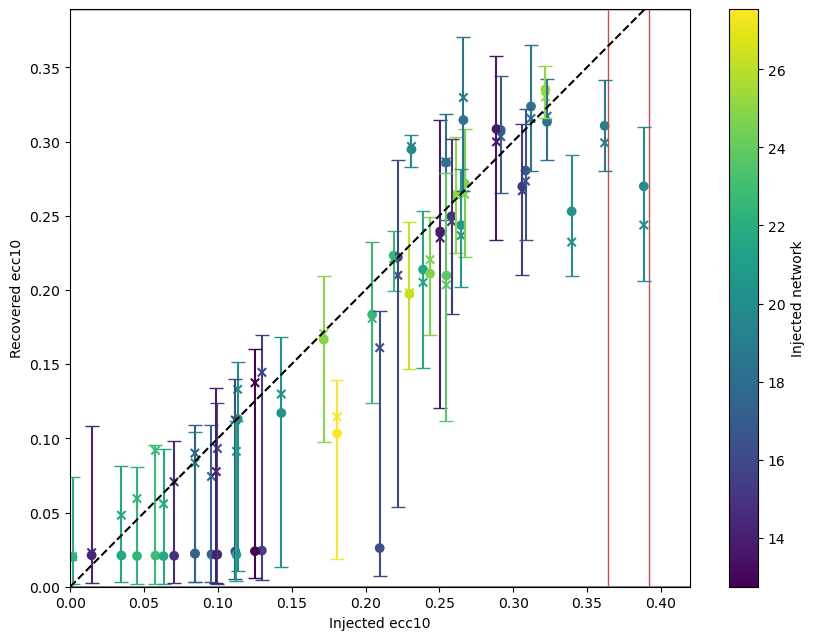

In [3]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections'
xlims = [0, 0.42]
ylims = [0, None]
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:43,  1.16it/s]


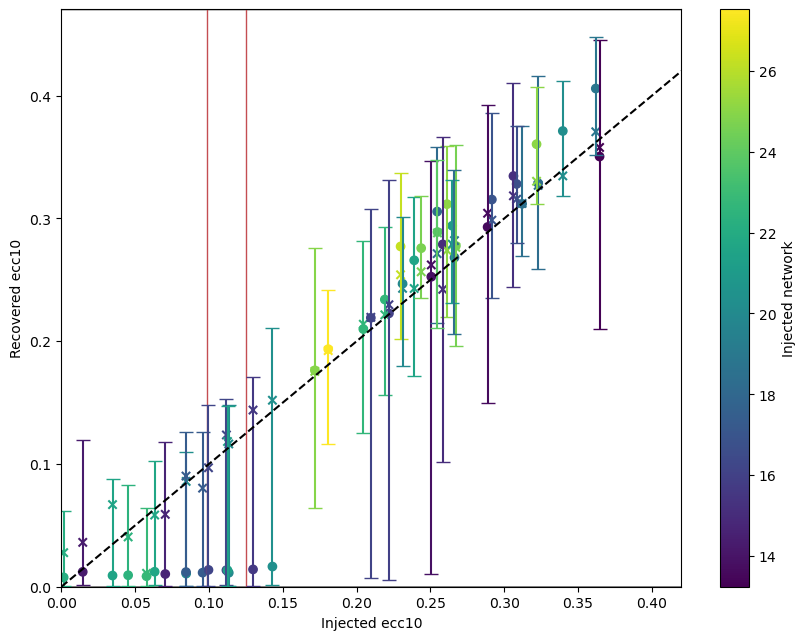

In [4]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v10/injections'
xlims = [0, 0.42]
ylims = [0, None]
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:26,  1.92it/s]


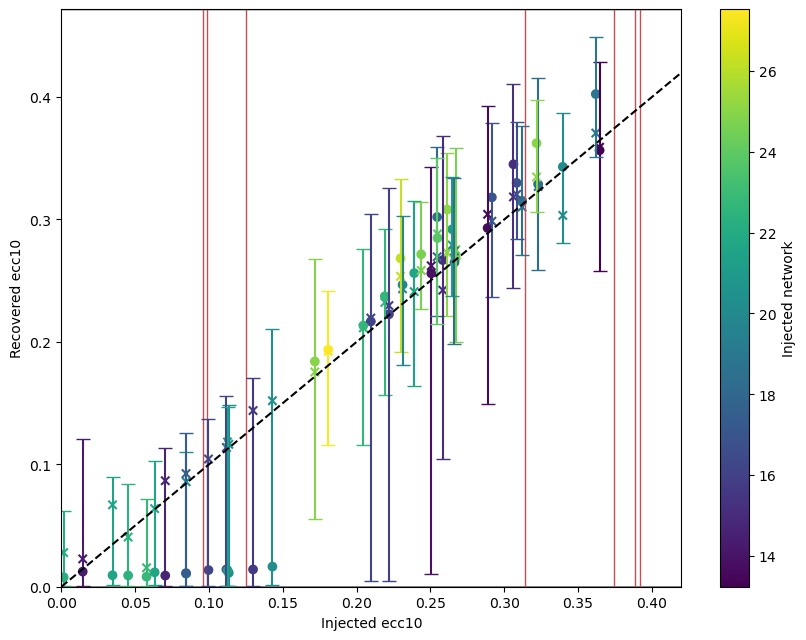

In [18]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v11/injections'
xlims = [0, 0.42]
ylims = [0, None]
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:45,  1.10it/s]


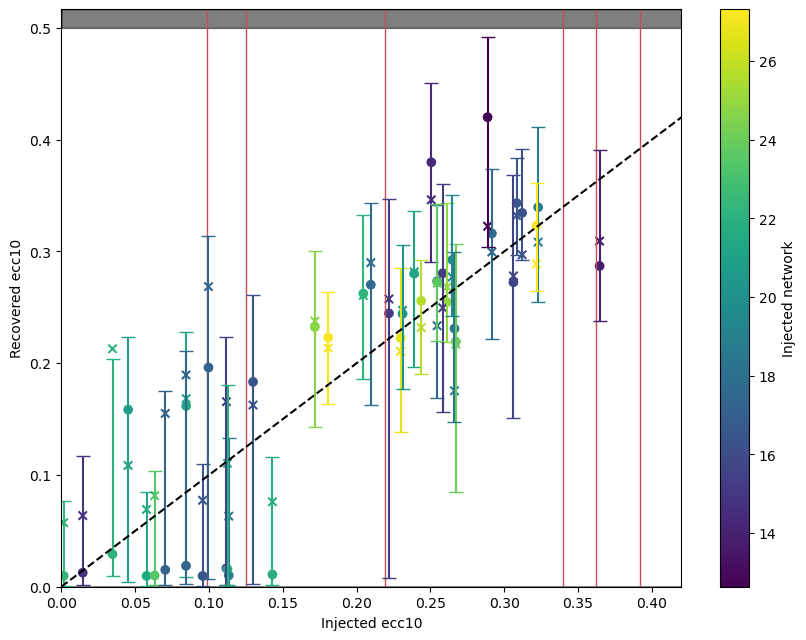

In [6]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v10/injections'
xlims = [0, 0.42]
ylims = [0, None]
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:46,  1.08it/s]


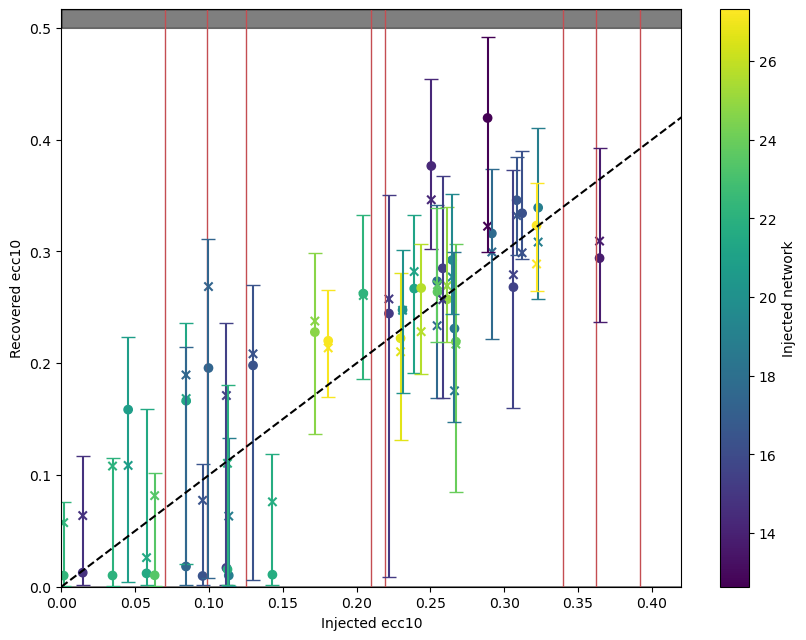

In [7]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v11/injections'
xlims = [0, 0.42]
ylims = [0, None]
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:31,  1.57it/s]


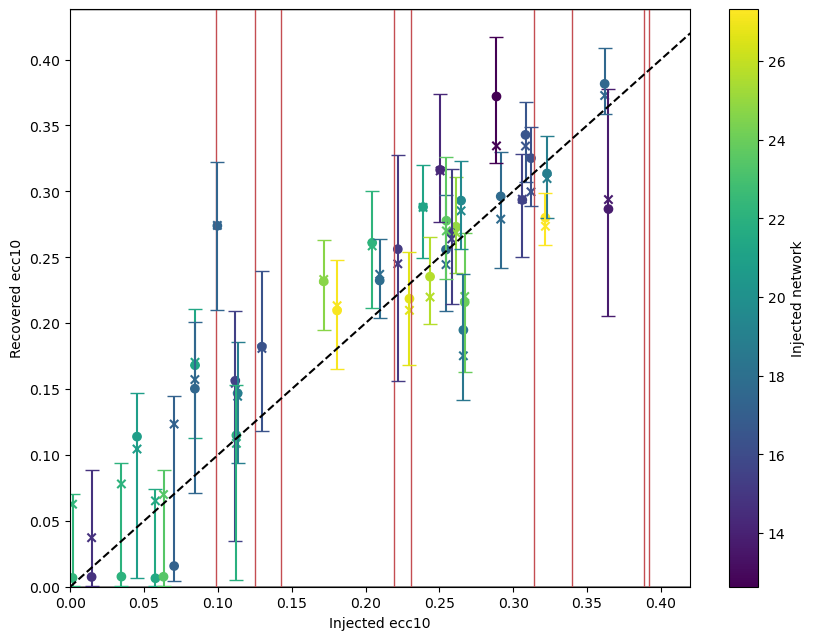

In [20]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v12/injections'
xlims = [0, 0.42]
ylims = [0, None]
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:25,  1.96it/s]


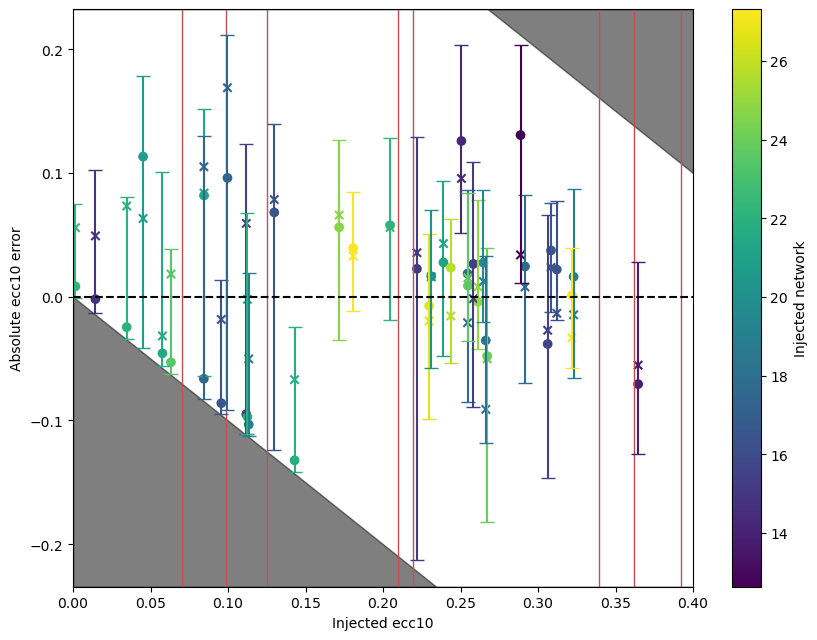

In [8]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'abs'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v11/injections'
xlims = [0, 0.4]
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:25,  1.96it/s]


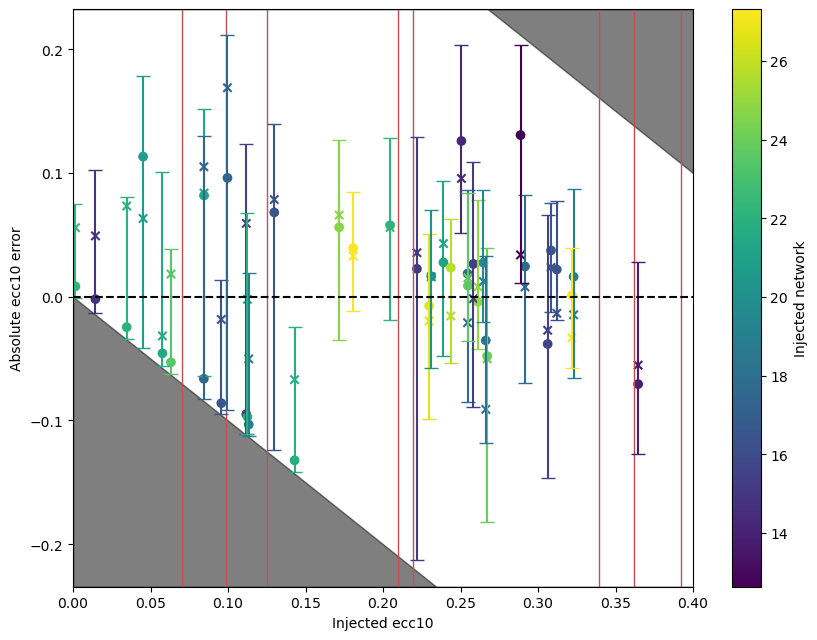

In [9]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'abs'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v11/injections'
xlims = [0, 0.4]
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:25,  1.99it/s]


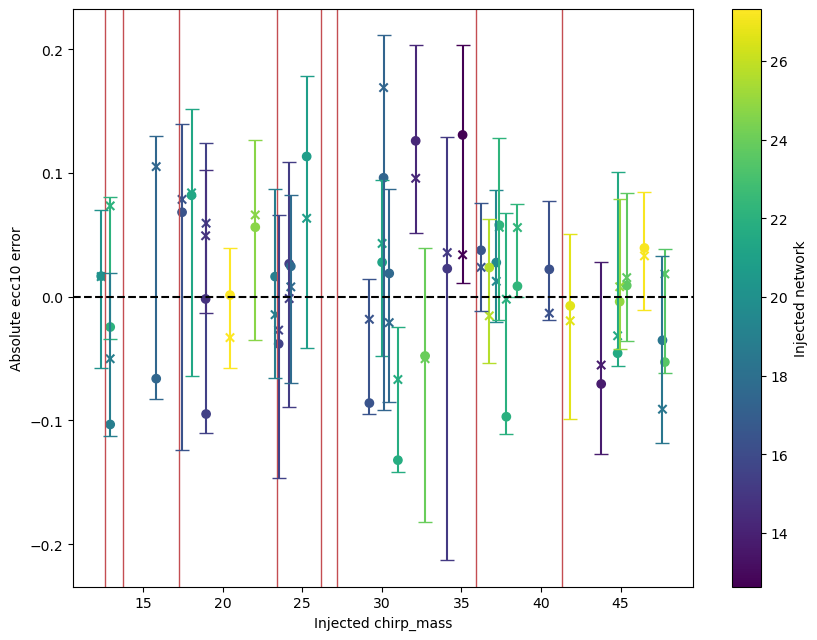

In [10]:
err_lbl = 'ecc10'
inj_lbl = 'chirp_mass'
colour_lbl = 'network'
err_type = 'abs'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v11/injections'
xlims = None
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:25,  1.96it/s]


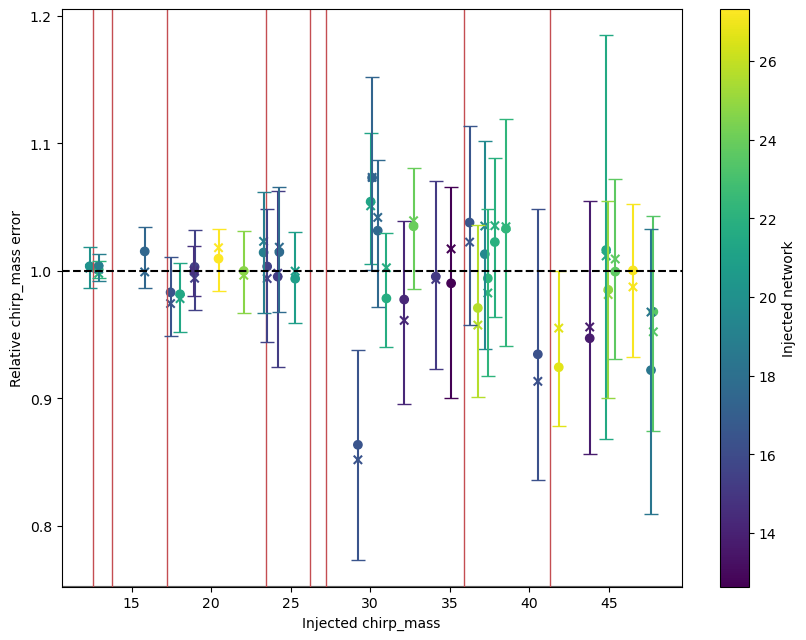

In [11]:
err_lbl = 'chirp_mass'
inj_lbl = 'chirp_mass'
colour_lbl = 'network'
err_type = 'rel'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v11/injections'
xlims = None
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:25,  1.94it/s]


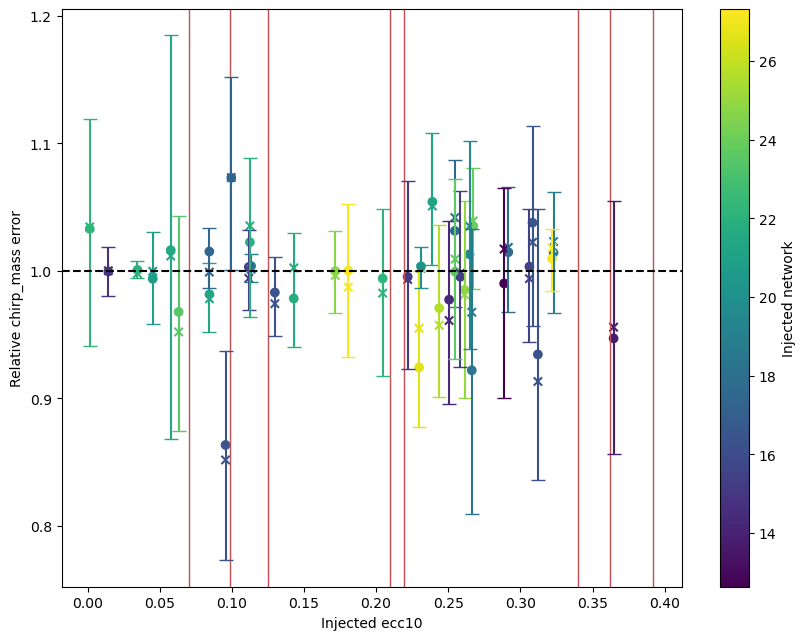

In [12]:
err_lbl = 'chirp_mass'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'rel'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v11/injections'
xlims = None
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:27,  1.85it/s]


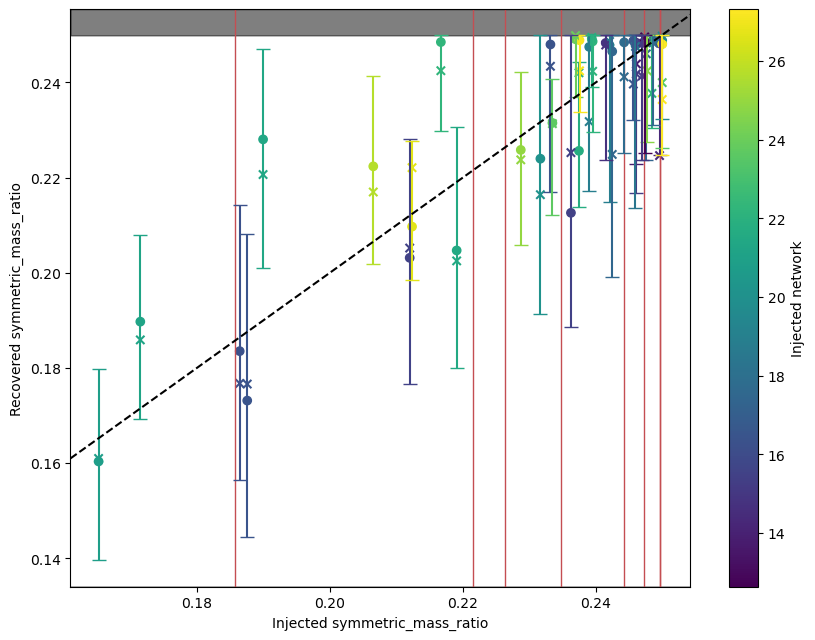

In [13]:
err_lbl = 'symmetric_mass_ratio'
inj_lbl = 'symmetric_mass_ratio'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v11/injections'
xlims = None
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

50it [00:25,  1.94it/s]


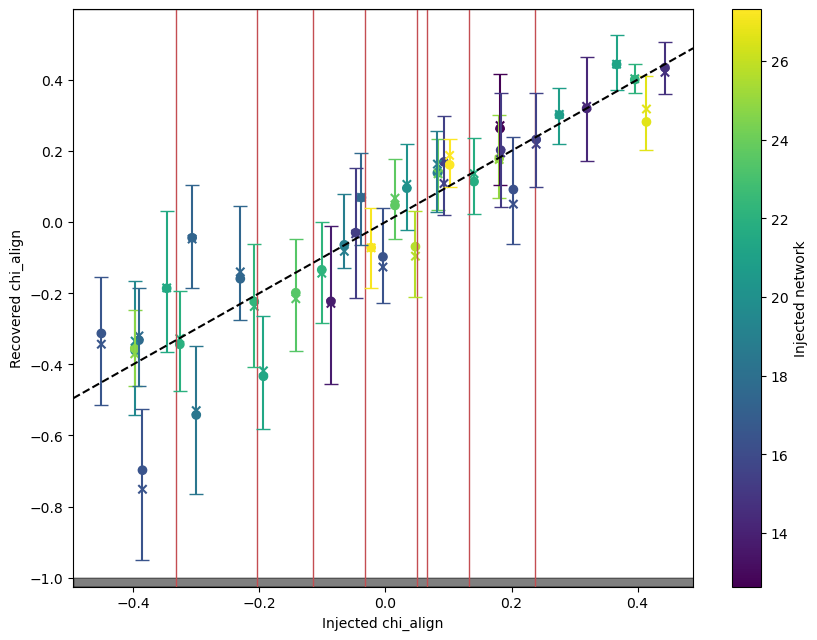

In [14]:
err_lbl = 'chi_align'
inj_lbl = 'chi_align'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v11/injections'
xlims = None
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims)

In [15]:
def plot_times(inj_lbl, injections_dir):

    stages = ['filter', 'analysis']
    times = {stage: [] for stage in stages}
    inj_params = []
    for i, inj_dir in tqdm(enumerate(sorted(os.listdir(injections_dir)))):

        # Check run finished
        inj_dir = os.path.join(injections_dir, inj_dir)
        check_dir = os.path.join(inj_dir, 'outdir/output')
        if 'corner.png' not in os.listdir(check_dir):
            continue

        # Read in times
        log_dir = os.path.join(inj_dir, 'outdir/log/')
        for fname in os.listdir(log_dir):
            filename = os.path.join(log_dir, fname)
            stage = fname.split('_')[0]
            if stage not in stages:
                continue
            with open(filename) as file:
                lines = [line.rstrip() for line in file]
            for line in lines[::-1]:
                if 'TimeExecute' in line:
                    time_exec = int(line.split(' ')[-1])
                    times[stage].append(time_exec)

        # Read in injection parameter
        inj_path = os.path.join(inj_dir, 'outdir/output/converted_injection_parameters.json')
        with open(inj_path, 'r') as f:
            inj_dict = json.load(f)
        inj_param = inj_dict['posterior_samples'][inj_lbl]
        inj_params.append(inj_param)

    # Make plot
    total = np.zeros(len(times[stages[0]]))
    for stage in stages:
        times[stage] = np.array(times[stage])/60
        plt.scatter(inj_params, times[stage], label=stage)
        total += times[stage]
    plt.scatter(inj_params, total, label='total')
    ylim_upper = plt.gca().get_ylim()[1]
    ls_dict = {0: 'solid', 1: 'dotted', 2: 'dashed', 3: 'dotted', 4: 'dashed', 5: 'dotted'}
    for i in np.arange(10, ylim_upper, 10):
        plt.axhline(i, c='k', alpha=0.5, ls=ls_dict[(i/10)%6], zorder=-1)
    plt.xlabel(f'Injected {inj_lbl}')
    plt.ylabel('Execute time / m')
    plt.legend()
    plt.ylim(0,)
    plt.show()

50it [00:00, 282.99it/s]


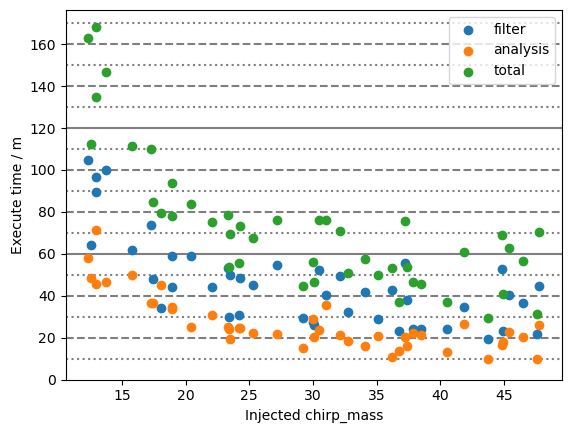

50it [00:00, 265.34it/s]


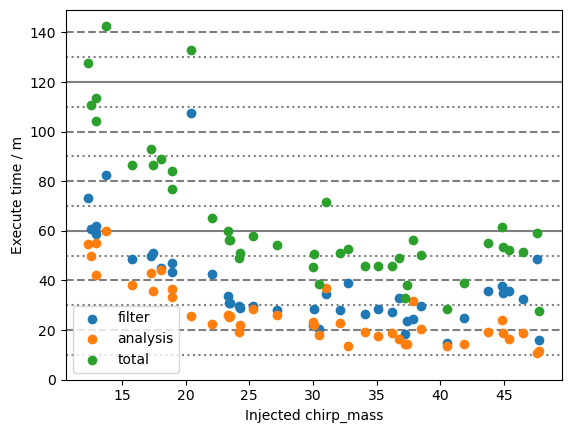

50it [00:00, 227.83it/s]


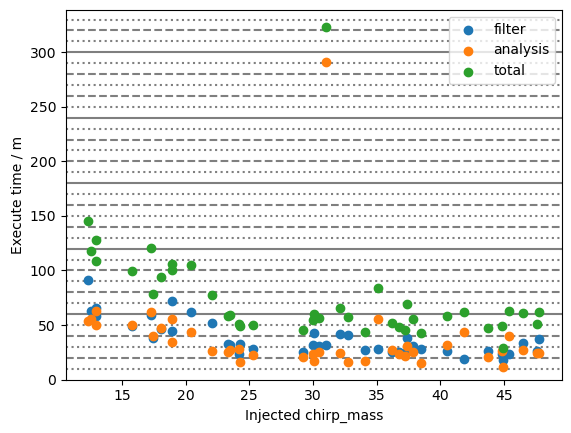

50it [00:00, 478.70it/s]


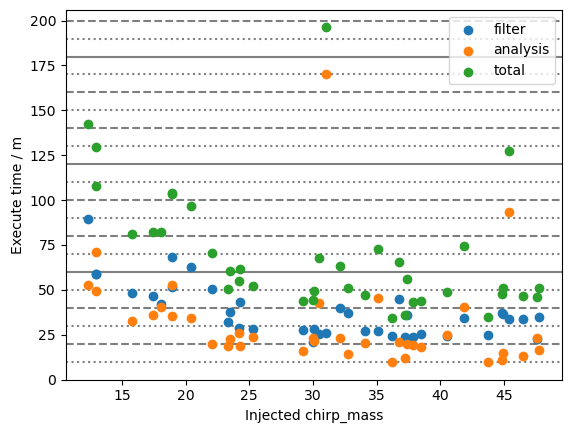

In [16]:
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v10/injections'
plot_times('chirp_mass', injections_dir)
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v11/injections'
plot_times('chirp_mass', injections_dir)
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v10/injections'
plot_times('chirp_mass', injections_dir)
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/gaussian_noise_50_v11/injections'
plot_times('chirp_mass', injections_dir)

50it [00:00, 215.93it/s]


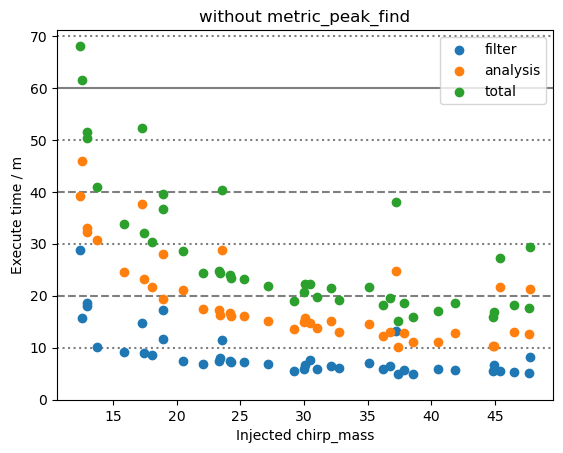

50it [00:00, 1570.36it/s]


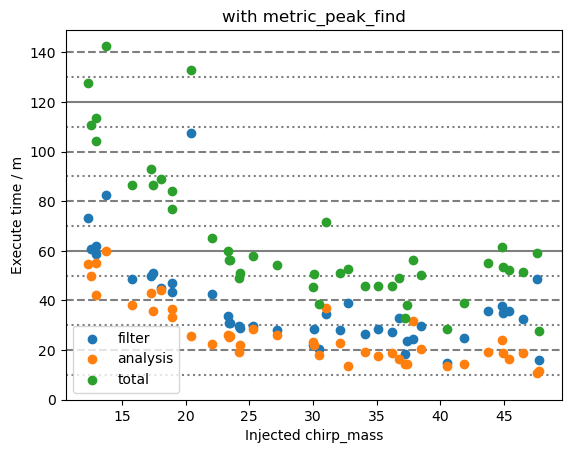

In [17]:
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v9/injections'
plt.title('without metric_peak_find')
plot_times('chirp_mass', injections_dir)
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v11/injections'
plt.title('with metric_peak_find')
plot_times('chirp_mass', injections_dir)

50it [00:24,  2.05it/s]


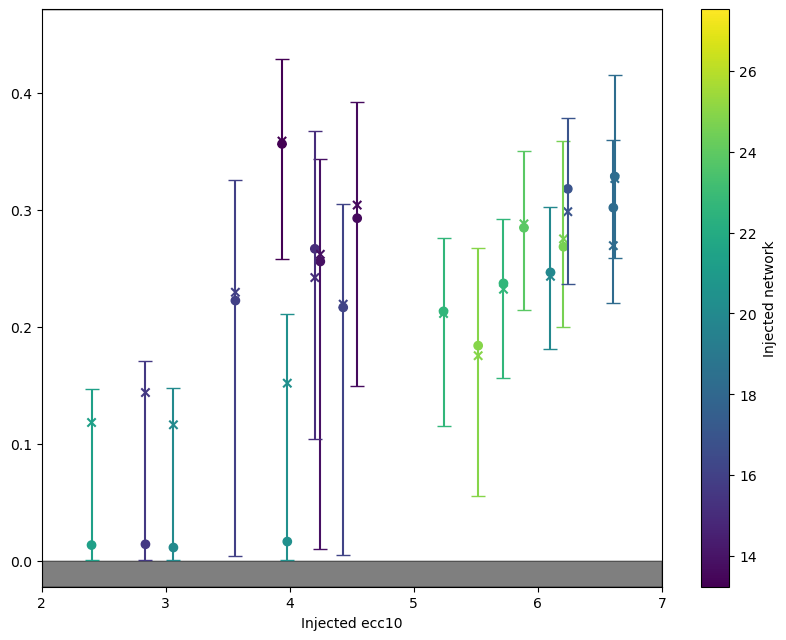

In [18]:
err_lbl = 'ecc10'
inj_lbl = 'ecc10'
colour_lbl = 'network'
err_type = 'base'
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v11/injections'
xlims = (2, 7)
ylims = None
summary_plot(err_lbl, inj_lbl, colour_lbl, injections_dir, err_type, xlims=xlims, ylims=ylims, ecc_harm_snr=True)